# Hotel Reviews — EDA and Data Cleaning

This notebook loads the Kaggle 515K Hotel Reviews dataset, runs exploratory analysis, and inspects cleaned review text and reviewer segments.

**Scope:** EDA and data cleaning inspection only. Dataset generation is handled by `src/absa/preprocess.py`.

# 0. Setup and Configuration

Imports, paths, display options, and NLTK tokenizer setup.

In [3]:
import os
import re
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import sent_tokenize

warnings.filterwarnings("ignore", category=FutureWarning)

# Display options
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 100)

# data.csv lives in the notebooks/ folder — same directory as this notebook.
DATA_PATH = "data.csv"
if not os.path.isfile(DATA_PATH):
    raise FileNotFoundError("data.csv not found. Place it in the notebooks/ folder alongside this notebook.")
# NLTK: download Punkt if missing (and punkt_tab for newer NLTK versions)
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt", quiet=True)

try:
    nltk.data.find("tokenizers/punkt_tab/english")
except LookupError:
    try:
        nltk.download("punkt_tab", quiet=True)
    except Exception:
        pass  # older NLTK may not need this resource

# Plot defaults: prefer a light grid if available
if "seaborn-v0_8-whitegrid" in plt.style.available:
    plt.style.use("seaborn-v0_8-whitegrid")
else:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        pass
sns.set_theme(style="whitegrid", font_scale=0.95)

# Configurable minimum sentence length (characters) after strip
MIN_SENTENCE_CHARS = 3

print("Setup complete.")
print("DATA_PATH:", os.path.abspath(DATA_PATH))


Setup complete.
DATA_PATH: C:\Users\rog\Desktop\Hotel-Review-Intelligence-Aspect-Sentiment-and-Rating-Impact-Analysis\data\data.xlsx
OUTPUT_DIR: C:\Users\rog\Desktop\Hotel-Review-Intelligence-Aspect-Sentiment-and-Rating-Impact-Analysis\outputs


# 1. Load Dataset

Load the raw CSV file, standardise `Review_Date` to ISO date strings (YYYY-MM-DD), then inspect shape, a sample, columns, and dtypes.

In [5]:
# Stop with a clear message if the dataset is not in data/
if not os.path.isfile(DATA_PATH):
    print("=" * 70)
    print("ERROR: Hotel review dataset not found.")
    print("Expected path:", os.path.abspath(DATA_PATH))
    print("Place the CSV file as:")
    print("  data/data.csv")
    print("=" * 70)
    raise FileNotFoundError(f"Missing dataset at {DATA_PATH}")

df = pd.read_csv(DATA_PATH, low_memory=False)

df["Review_Date"] = pd.to_datetime(df["Review_Date"], errors="coerce")
df["Review_Date"] = df["Review_Date"].dt.strftime("%Y-%m-%d")

print("Dataset shape (rows, columns):", df.shape)
print()
print("First 5 rows:")
print(df.head())
print()
print("Column names:")
print(list(df.columns))
print()
print("Data types:")
print(df.dtypes)


Dataset shape (rows, columns): (515738, 17)

First 5 rows:
                                               Hotel_Address  Additional_Number_of_Scoring Review_Date  Average_Score  \
0   s Gravesandestraat 55 Oost 1092 AA Amsterdam Netherlands                           194  2017-03-08            7.7   
1   s Gravesandestraat 55 Oost 1092 AA Amsterdam Netherlands                           194  2017-03-08            7.7   
2   s Gravesandestraat 55 Oost 1092 AA Amsterdam Netherlands                           194  2017-07-31            7.7   
3   s Gravesandestraat 55 Oost 1092 AA Amsterdam Netherlands                           194  2017-07-31            7.7   
4   s Gravesandestraat 55 Oost 1092 AA Amsterdam Netherlands                           194  2017-07-24            7.7   

    Hotel_Name Reviewer_Nationality  \
0  Hotel Arena              Russia    
1  Hotel Arena             Ireland    
2  Hotel Arena           Australia    
3  Hotel Arena      United Kingdom    
4  Hotel Arena     

# 2. Basic Data Quality Checks

Missing values, duplicates, `Reviewer_Score` statistics and distribution, hotel coverage, and geography / tags.


Missing value count and percentage by column:
                                            missing_count  missing_pct
lng                                                  3268     0.633655
lat                                                  3268     0.633655
Positive_Review                                         0     0.000000
days_since_review                                       0     0.000000
Tags                                                    0     0.000000
Reviewer_Score                                          0     0.000000
Total_Number_of_Reviews_Reviewer_Has_Given              0     0.000000
Review_Total_Positive_Word_Counts                       0     0.000000
Hotel_Address                                           0     0.000000
Additional_Number_of_Scoring                            0     0.000000
Review_Total_Negative_Word_Counts                       0     0.000000
Negative_Review                                         0     0.000000
Reviewer_Nationality           

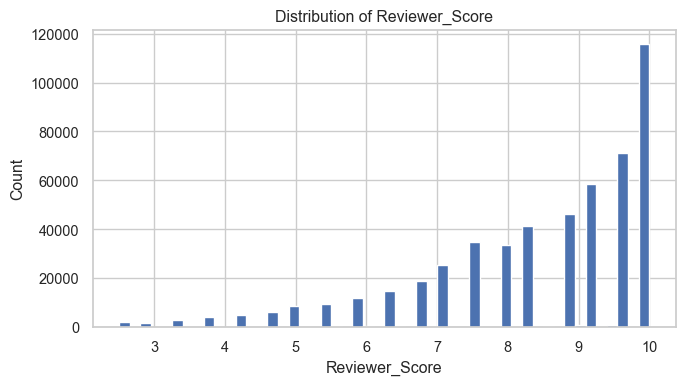


Number of unique hotels: 1492

Top 10 hotels by number of reviews:
Hotel_Name
Britannia International Hotel Canary Wharf           4789
Strand Palace Hotel                                  4256
Park Plaza Westminster Bridge London                 4169
Copthorne Tara Hotel London Kensington               3578
DoubleTree by Hilton Hotel London Tower of London    3212
Grand Royale London Hyde Park                        2958
Holiday Inn London Kensington                        2768
Hilton London Metropole                              2628
Millennium Gloucester Hotel London                   2565
Intercontinental London The O2                       2551
Name: count, dtype: int64

Top countries (from Reviewer_Nationality):
Reviewer_Nationality
United Kingdom               245246
United States of America      35437
Australia                     21686
Ireland                       14827
United Arab Emirates          10235
Saudi Arabia                   8951
Netherlands                    877

In [7]:
# Missing values
missing = df.isna().sum()
missing_pct = 100 * missing / len(df)
missing_tbl = (
    pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
    .sort_values("missing_count", ascending=False)
)
print("Missing value count and percentage by column:")
print(missing_tbl)

# Duplicates
dup_count = df.duplicated().sum()
print(f"\nDuplicate row count: {dup_count}")

# Reviewer_Score
if "Reviewer_Score" in df.columns:
    s = df["Reviewer_Score"]
    print("\nReviewer_Score — describe():")
    print(s.describe())
    print("min, max, mean, median:", float(s.min()), float(s.max()), float(s.mean()), float(s.median()))
    fig, ax = plt.subplots(figsize=(7, 4))
    s.dropna().hist(bins=50, ax=ax, edgecolor="white")
    ax.set_title("Distribution of Reviewer_Score")
    ax.set_xlabel("Reviewer_Score")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("Column Reviewer_Score not found in dataset.")

# Unique hotels
if "Hotel_Name" in df.columns:
    n_hotels = df["Hotel_Name"].nunique()
    print(f"\nNumber of unique hotels: {n_hotels}")
    print("\nTop 10 hotels by number of reviews:")
    print(df["Hotel_Name"].value_counts().head(10))
else:
    print("Column Hotel_Name not found.")

# Countries / location — Reviewer_Nationality; hotel country from full Hotel_Address (comma-split is unreliable)
if "Reviewer_Nationality" in df.columns:
    print("\nTop countries (from Reviewer_Nationality):")
    print(df["Reviewer_Nationality"].value_counts().head(12))

if "Hotel_Address" in df.columns:
    def extract_hotel_country(address):
        # Match end of full address string (not comma-split). Longer suffixes first via sort.
        if pd.isna(address):
            return np.nan
        address = str(address).strip()
        # (suffix as in data, label for counts) — extend list to shrink "Unknown"
        suffix_map = [
            ("Bosnia and Herzegovina", "Bosnia and Herzegovina"),
            ("Czech Republic", "Czech Republic"),
            ("North Macedonia", "North Macedonia"),
            ("Macedonia", "North Macedonia"),  # legacy spelling; matched after "North Macedonia" by length
            ("United Kingdom", "United Kingdom"),
            ("Netherlands", "Netherlands"),
            ("Switzerland", "Switzerland"),
            ("Luxembourg", "Luxembourg"),
            ("Liechtenstein", "Liechtenstein"),
            ("France", "France"),
            ("Spain", "Spain"),
            ("Italy", "Italy"),
            ("Austria", "Austria"),
            ("Germany", "Germany"),
            ("Belgium", "Belgium"),
            ("Portugal", "Portugal"),
            ("Ireland", "Ireland"),
            ("Greece", "Greece"),
            ("Poland", "Poland"),
            ("Hungary", "Hungary"),
            ("Romania", "Romania"),
            ("Bulgaria", "Bulgaria"),
            ("Croatia", "Croatia"),
            ("Slovakia", "Slovakia"),
            ("Slovenia", "Slovenia"),
            ("Estonia", "Estonia"),
            ("Latvia", "Latvia"),
            ("Lithuania", "Lithuania"),
            ("Finland", "Finland"),
            ("Sweden", "Sweden"),
            ("Norway", "Norway"),
            ("Denmark", "Denmark"),
            ("Iceland", "Iceland"),
            ("Malta", "Malta"),
            ("Cyprus", "Cyprus"),
            ("Serbia", "Serbia"),
            ("Montenegro", "Montenegro"),
            ("Albania", "Albania"),
            ("Moldova", "Moldova"),
            ("Ukraine", "Ukraine"),
            ("Belarus", "Belarus"),
            ("Russia", "Russia"),
            ("Turkey", "Turkey"),
            ("Andorra", "Andorra"),
            ("Monaco", "Monaco"),
            ("San Marino", "San Marino"),
        ]
        for suffix, label in sorted(suffix_map, key=lambda t: -len(t[0])):
            if address.endswith(suffix):
                return label
        return "Unknown"

    df["Hotel_Country"] = df["Hotel_Address"].map(extract_hotel_country)
    print("\nHotel country (from Hotel_Address, known suffixes only):")
    print(df["Hotel_Country"].value_counts())

# Tags — sample and common values
if "Tags" in df.columns:
    print("\nSample Tags values (up to 5 non-null):")
    for i, t in enumerate(df["Tags"].dropna().head(5)):
        print(f"  {i+1}. {t!r}")
    print("\nMost common exact Tags strings (top 5):")
    print(df["Tags"].value_counts().head(5))
else:
    print("No Tags column present.")


# 3. Review Text Cleaning Preparation

`PLACEHOLDER_PATTERN` / `is_empty_review` detect non-informative text (e.g. *No Positive*, *Nothing to complain about*). `clean_review_text` strips and collapses spaces, then returns `""` for placeholders so saved fields stay readable. Word counts are computed **after** cleaning (placeholders → 0 words). EDA plots use those counts.


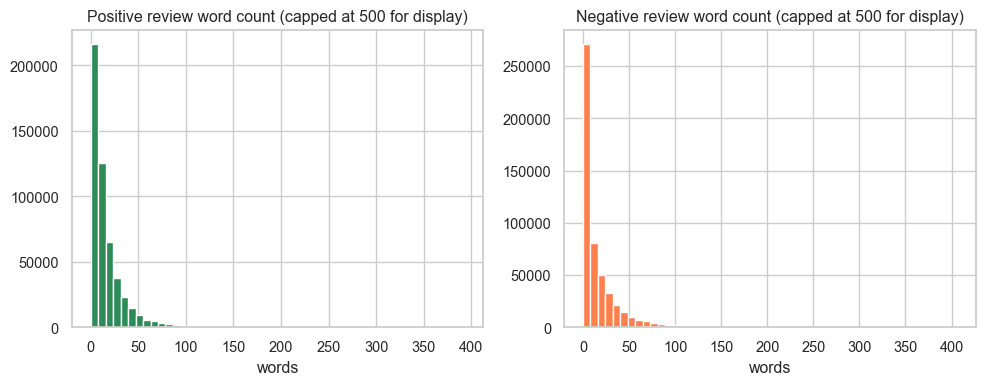

Average positive words: 16.32
Average negative words: 17.29


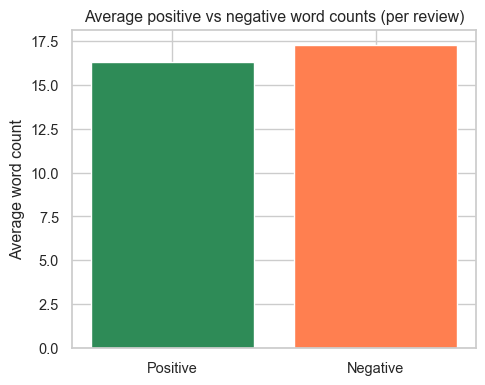

In [9]:
# Placeholder: whole-field match (case-insensitive, allows surrounding whitespace)
PLACEHOLDER_PATTERN = re.compile(
    r"^\s*("
    r"no positive|no negative|nothing|nothing really|nothing at all|"
    r"n/a|n a|na|none|nil|"
    r"no complaints?|"
    r"nothing to dislike|nothing to complain about"
    r")\s*$",
    re.IGNORECASE,
)


def is_empty_review(text):
    """True for NaN, blank, or known non-informative review placeholders only."""
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return True
    t = str(text).strip()
    if not t:
        return True
    return bool(PLACEHOLDER_PATTERN.match(t))


def clean_review_text(text):
    """Strip, collapse spaces; drop placeholders so they become \"\" (readable case preserved)."""
    if pd.isna(text):
        return ""
    s = str(text).strip()
    s = re.sub(r"\s+", " ", s)
    if is_empty_review(s):
        return ""
    return s


def word_count_non_empty(text):
    """From cleaned text: 0 for empty/placeholder, else word count."""
    if not text or is_empty_review(text):
        return 0
    return len(str(text).split())


# Build cleaned columns, then recompute word counts from cleaned text
for col, out_col in [("Positive_Review", "positive_review_clean"), ("Negative_Review", "negative_review_clean")]:
    if col in df.columns:
        df[out_col] = df[col].map(clean_review_text)
    else:
        print(f"Warning: expected column {col!r} not found; filling {out_col!r} with empty strings.")
        df[out_col] = ""

# Word counts (after cleaning; empty placeholder fields -> 0)
df["positive_word_count"] = df["positive_review_clean"].map(word_count_non_empty)
df["negative_word_count"] = df["negative_review_clean"].map(word_count_non_empty)
df["total_word_count"] = df["positive_word_count"] + df["negative_word_count"]

# Distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["positive_word_count"].clip(upper=500).hist(bins=50, ax=axes[0], color="seagreen", edgecolor="white")
axes[0].set_title("Positive review word count (capped at 500 for display)")
axes[0].set_xlabel("words")

df["negative_word_count"].clip(upper=500).hist(bins=50, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Negative review word count (capped at 500 for display)")
axes[1].set_xlabel("words")
plt.tight_layout()
plt.show()

avg_pos = df["positive_word_count"].mean()
avg_neg = df["negative_word_count"].mean()
print(f"Average positive words: {avg_pos:.2f}")
print(f"Average negative words: {avg_neg:.2f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Positive", "Negative"], [avg_pos, avg_neg], color=["seagreen", "coral"], edgecolor="white")
ax.set_ylabel("Average word count")
ax.set_title("Average positive vs negative word counts (per review)")
plt.tight_layout()
plt.show()

# 4. Reviewer Segment Extraction from `Tags`

Map `Tags` to **Business / Couple / Family / Solo / Group / Unknown** using simple keyword rules.


Value counts: reviewer_segment
reviewer_segment
Couple      237456
Family       86155
Business     82939
Group        59060
Solo         50128
Name: count, dtype: int64


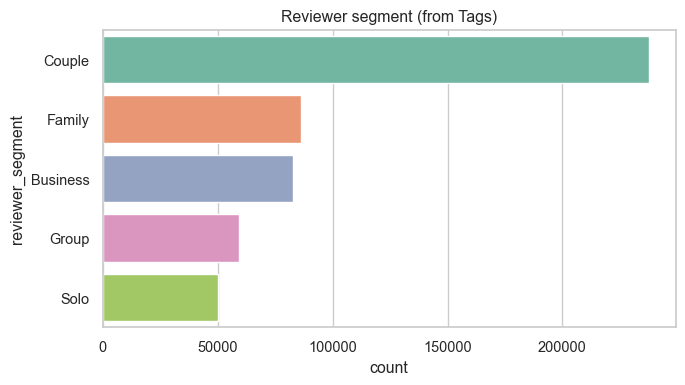

In [11]:
def extract_reviewer_segment(tags):
    if pd.isna(tags) or tags is None or str(tags).strip() == "":
        return "Unknown"
    raw = str(tags)
    # Kaggle format is often a stringified list, e.g. "['Leisure trip', 'Couple']"
    try:
        items = ast.literal_eval(raw)
        blob = " ".join(str(x) for x in items).lower()
    except (ValueError, SyntaxError, TypeError):
        blob = raw.lower()

    # Order matters: business / family / solo / group before couple
    if "business trip" in blob:
        return "Business"
    if "family" in blob:
        return "Family"
    if "solo traveler" in blob:
        return "Solo"
    if "travelers with friends" in blob or re.search(r"\bgroup\b", blob):
        return "Group"
    if "couple" in blob:
        return "Couple"
    return "Unknown"


if "Tags" in df.columns:
    df["reviewer_segment"] = df["Tags"].map(extract_reviewer_segment)
else:
    df["reviewer_segment"] = "Unknown"

print("Value counts: reviewer_segment")
print(df["reviewer_segment"].value_counts())

fig, ax = plt.subplots(figsize=(7, 4))
order = df["reviewer_segment"].value_counts().index.tolist()
sns.countplot(data=df, y="reviewer_segment", order=order, ax=ax, palette="Set2", edgecolor="white")
ax.set_title("Reviewer segment (from Tags)")
plt.tight_layout()
plt.show()


# 5. Summary

- **Dataset:** 515,738 reviews across 1,492 hotels. No duplicate rows. `Reviewer_Score` ranges 2.5–10.0, median ~8.0.
- **Text cleaning:** Placeholder values (`No Positive`, `Nothing`, etc.) normalised to empty strings. Average ~20 positive words and ~17 negative words per review after cleaning.
- **Reviewer segments:** Couple (46%) › Family (17%) › Business (16%) › Group (11%) › Solo (10%), derived from `Tags`.
- **Dataset generation:** handled by `src/absa/preprocess.py` — outputs `outputs/sentences.csv` and `outputs/clean_reviews_stage1.csv`.